# Incremental Capstone 10 - CNN - Face Mask Detection

In this notebook, we build a convolutional neural network (CNN) classifier for the  Face Mask Detection dataset using PyTorch's `nn.Sequential` module.

## Notebook set-up

### Imports

In [1]:
# Standard library imports
from pathlib import Path
import math

# Third party imports
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    confusion_matrix, roc_curve, auc, 
    precision_recall_curve, average_precision_score
)

from sklearn.preprocessing import label_binarize
from torchvision import datasets, transforms
from torch.utils.data import (
    DataLoader, 
    random_split
)

# Set random seeds for reproducibility
torch.manual_seed(315)
np.random.seed(315)

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


### Hyperparameters

In [2]:
batch_size = 50 #10000 # Training images come in 5 batches of 10,000  -- for CPU Processing
learning_rate = 1e-3
dropout_rate = 0.25  # 0.5
epochs = 100
print_every = 10 # Print training progress every n epochs
image_size = 128 # 64 # 128


## 1. Load and Preprocess Face Mask data

The Face Mask data set contains colour (3 channel RGB) images which are divided into 2 classes: **with_mask** : **without_mask** </br>
Standard CNN sequential models (fully connected) require fixed-sized images as input.</br>
The images of the data set are of varied dimensions. In order to build/train a CNN model, the images will have to be resized.</br>
For simplicity/computational (CPU) considerations, we'll start with (64X64) sized images. </br>
Initially this model will be built/trained using grayscale (as per CPU performance considerations listed above).</br>
If time permits I'll circle back and try larger (128X128) images and try using RGB images to see if and how that affects model performance.</br>
</br>
**Computational Performance Plan Summary**:</br>
    **1.** Use smaller fixed image size (64X64)</br>
    **2.** Use GrayScale (to reduce the amount of data being crunched)</br>
    **3.** Use a small subset of data (400 images - 200 masks/200 unmasks) during the initial architecture design and testing</br>
  

### 1.1. Load datasets

In [3]:
# Make sure data directory exists

# For Subset of Data
#data_dir = Path('../../../data/Capstone10/data-subset-400')
#data_dir = Path('../../../data/Capstone10/data-subset-1000')

# For Full Dataset
data_dir = Path('../../../data/Capstone10/data')

# No need to make the directory
#data_dir.mkdir(parents=True, exist_ok=True)

# Data preprocessing: convert to grayscale, tensor, and normalize
transform = transforms.Compose([
                                #transforms.Grayscale(num_output_channels=1), # Uncomment for GreyScale
                                transforms.Resize((image_size, image_size)),
                                transforms.ToTensor(),
                                transforms.Normalize((0.5,), (0.5,))
                            ])

# Load full dataset
full_dataset = datasets.ImageFolder(root=data_dir, 
                               transform=transform)

# Check class-to-label mapping
print(full_dataset.class_to_idx)

class_names = full_dataset.classes
print(f'Class Names: {class_names}')

{'with_mask': 0, 'without_mask': 1}
Class Names: ['with_mask', 'without_mask']


### 1.2 **Plot Sample Images** 

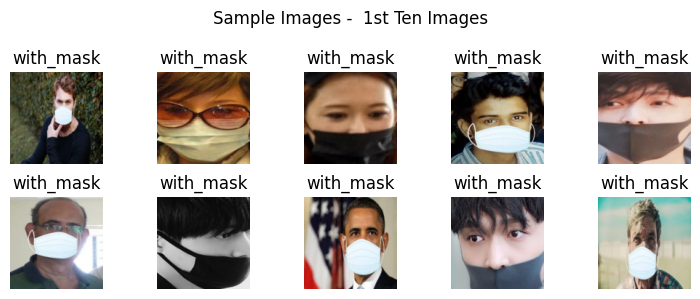

In [4]:

# Plot Sample of Images
def PlotSampleImages(target_dataset):

    # Get class names from dataset
    class_names = list(target_dataset.class_to_idx.keys())

    # Plot first 10 images from the dataset
    ncols = 5
    nrows = 2

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*1.5, nrows*1.5))
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        # Get image and label from dataset
        img, label = target_dataset[i]
        
        # Unnormalize and squeeze for plotting
        img = img * 0.5 + 0.5
        #img = img.numpy().squeeze()           # For GreyScale Images
        img = img.numpy().transpose(1, 2, 0)  # For RGB Images
        ax.set_title(class_names[label])
        #ax.imshow(img, cmap='gray')           # For GreyScale Images
        ax.imshow(img)                         # For RGB Images
        ax.axis('off')

    plt.suptitle('Sample Images -  1st Ten Images')
    plt.tight_layout()
    plt.show()

PlotSampleImages(full_dataset)


### 1.3 **Split Into Test/Train Datasets** 
ImageFolder returns tuples (image, label) into a dataset.</br>
We do not get test/train split automatically like when call CFAR10().</br>
We have to create the split by hand. After research, Pytorch() has a utility function</br>
to accomplish this: **random_split()**. Quicker to use this than to create splits manually.</br>


In [5]:
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

train_full_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

# Now your pattern works
X_train_full = torch.stack([img for img, _ in train_full_dataset]).to(device)

# For Binary Classification - BCELoss needs float32 + .unsqueeze(1)
#y_train_full = torch.tensor([label for _, label in train_full_dataset], dtype=torch.float32).unsqueeze(1).to(device)
y_train_full = torch.tensor([label for _, label in train_full_dataset], dtype=torch.long)

X_test = torch.stack([img for img, _ in test_dataset]).to(device)
#y_test = torch.tensor([label for _, label in test_dataset], dtype=torch.float32).unsqueeze(1).to(device)
y_test = torch.tensor([label for _, label in test_dataset], dtype=torch.long)

# Split training into train and validation (80/20)
n_train = int(0.8 * len(X_train_full))
indices = torch.randperm(len(X_train_full))

X_train = X_train_full[indices[:n_train]]
y_train = y_train_full[indices[:n_train]]
X_val = X_train_full[indices[n_train:]]
y_val = y_train_full[indices[n_train:]]

print('##########################################################')
print('Print Train, Val and Test Shapes')
print('##########################################################')
print(f'X_train shape: {X_train.shape}, device: {X_train.device}')
print(f'y_train shape: {y_train.shape}, device: {y_train.device}')
print(f'X_val shape: {X_val.shape}, device: {X_val.device}')
print(f'y_val shape: {y_val.shape}, device: {y_val.device}')
print(f'X_test shape: {X_test.shape}, device: {X_test.device}')
print(f'y_test shape: {y_test.shape}, device: {y_test.device}')
print('##########################################################')
print()
print()

# Useful for stopping processing in cell
#raise Exception("Stopping Notebook Execution Here!!!")

/usr/local/lib/python3.10/dist-packages/PIL/Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


##########################################################
Print Train, Val and Test Shapes
##########################################################
X_train shape: torch.Size([4833, 3, 128, 128]), device: cpu
y_train shape: torch.Size([4833]), device: cpu
X_val shape: torch.Size([1209, 3, 128, 128]), device: cpu
y_val shape: torch.Size([1209]), device: cpu
X_test shape: torch.Size([1511, 3, 128, 128]), device: cpu
y_test shape: torch.Size([1511]), device: cpu
##########################################################




### 1.4 **Create DataLoader Objects** 

In [6]:
# Create TensorDatasets
train_tensor_dataset = torch.utils.data.TensorDataset(X_train, y_train)
val_tensor_dataset = torch.utils.data.TensorDataset(X_val, y_val)
test_tensor_dataset = torch.utils.data.TensorDataset(X_test, y_test)

# Create DataLoaders
train_loader = DataLoader(
                            train_tensor_dataset,
                            batch_size=batch_size,
                            shuffle=True
                        )

val_loader = DataLoader(
                            val_tensor_dataset,
                            batch_size=batch_size,
                            shuffle=False
                        )

test_loader = DataLoader(
                            test_tensor_dataset,
                            batch_size=batch_size,
                            shuffle=False
                        )

print('##########################################################')
print('Print DataLoader Batch Sizes')
print('##########################################################')
print(f'Training batches: {len(train_loader)}')
print(f'Validation batches: {len(val_loader)}')
print(f'Test batches: {len(test_loader)}')
print('##########################################################')
print()
print()



#raise Exception("Stopping Notebook Execution Here!!!")

##########################################################
Print DataLoader Batch Sizes
##########################################################
Training batches: 97
Validation batches: 25
Test batches: 31
##########################################################




## 2. Build CNN classifier with nn.Sequential

We build a convolutional neural network using `nn.Sequential`. The CNN uses convolutional layers to extract spatial features from the 32x32x1 grayscale images before classification.

### 2.1. Define model architecture

In [7]:
# Input: 1 x 64 x 64 (grayscale)


# Model GreyScale - 64x64
# model = nn.Sequential(

#     # Block 1: 1 -> 64 channels, 64x64 -> 32x32
#     nn.Conv2d(1, 64, kernel_size=3, padding=1),      # [1, 64, 64] -> [64, 64, 64]
#     nn.BatchNorm2d(64),
#     nn.ReLU(),
#     nn.MaxPool2d(2, 2),                               # [64, 64, 64] -> [64, 32, 32]
#     nn.Dropout(dropout_rate),

#     # Block 2: 64 -> 32 channels, 32x32 -> 16x16
#     nn.Conv2d(64, 32, kernel_size=3, padding=1),      # [64, 32, 32] -> [32, 32, 32]
#     nn.BatchNorm2d(32),
#     nn.ReLU(),
#     nn.MaxPool2d(2, 2),                               # [32, 32, 32] -> [32, 16, 16]
#     nn.Dropout(dropout_rate),

#     # Block 3: 32 -> 16 channels, 16x16 -> 8x8
#     nn.Conv2d(32, 16, kernel_size=3, padding=1),      # [32, 16, 16] -> [16, 16, 16]
#     nn.BatchNorm2d(16),
#     nn.ReLU(),
#     nn.MaxPool2d(2, 2),                               # [16, 16, 16] -> [16, 8, 8]
#     nn.Dropout(dropout_rate),

#     # Classifier
#     nn.Flatten(),                                      # 16 * 8 * 8 = 1024
#     nn.Linear(16 * 8 * 8, 128),
#     nn.ReLU(),
#     nn.Dropout(dropout_rate),

#     # If using binary classification - 1 output node [0, 1]
#     # Existing frame work requires rework in training/validation of torch.max() 
#     # when calculating prediction, since no longer 2 classes [0,1]
#     # BCELoss() loss function would be used. 
#     # torch.max() is for multi-classification
#     # nn.Linear(128, 1),
#     # nn.Sigmoid()

#     # If we want to use existing training/validation framework, we need to output 2 neurons
#     # then the existing multi-class model/framework will work as is.
#     # then CrossEntropyLoss() function can be used
#     nn.Linear(128, 2)

# ).to(device)

# Model RGB - 64x64
# model = nn.Sequential(

#     # Block 1: 1 -> 64 channels, 64x64 -> 32x32
#     nn.Conv2d(3, 64, kernel_size=3, padding=1),      # [3, 64, 64] -> [64, 64, 64]
#     nn.BatchNorm2d(64),
#     nn.ReLU(),
#     nn.MaxPool2d(2, 2),                               # [64, 64, 64] -> [64, 32, 32]
#     nn.Dropout(dropout_rate),

#     # Block 2: 64 -> 32 channels, 32x32 -> 16x16
#     nn.Conv2d(64, 32, kernel_size=3, padding=1),      # [64, 32, 32] -> [32, 32, 32]
#     nn.BatchNorm2d(32),
#     nn.ReLU(),
#     nn.MaxPool2d(2, 2),                               # [32, 32, 32] -> [32, 16, 16]
#     nn.Dropout(dropout_rate),

#     # Block 3: 32 -> 16 channels, 16x16 -> 8x8
#     nn.Conv2d(32, 16, kernel_size=3, padding=1),      # [32, 16, 16] -> [16, 16, 16]
#     nn.BatchNorm2d(16),
#     nn.ReLU(),
#     nn.MaxPool2d(2, 2),                               # [16, 16, 16] -> [16, 8, 8]
#     nn.Dropout(dropout_rate),

#     # Classifier
#     nn.Flatten(),                                      # 16 * 8 * 8 = 1024
#     nn.Linear(16 * 8 * 8, 128),
#     nn.ReLU(),
#     nn.Dropout(dropout_rate),

#     # If using binary classification - 1 output node [0, 1]
#     # Existing frame work requires rework in training/validation of torch.max() 
#     # when calculating prediction, since no longer 2 classes [0,1]
#     # BCELoss() loss function would be used. 
#     # torch.max() is for multi-classification
#     # nn.Linear(128, 1),
#     # nn.Sigmoid()

#     # If we want to use existing training/validation framework, we need to output 2 neurons
#     # then the existing multi-class model/framework will work as is.
#     # then CrossEntropyLoss() function can be used
#     nn.Linear(128, 2)

# ).to(device)

# Model GreyScale 128x128
# model = nn.Sequential(

#     # Block 1: 1 -> 128 channels, 128x128 -> 64x64
#     nn.Conv2d(1, 128, kernel_size=3, padding=1),       # [1, 128, 128] -> [128, 128, 128]
#     nn.BatchNorm2d(128),
#     nn.ReLU(),
#     nn.MaxPool2d(2, 2),                                 # [128, 128, 128] -> [128, 64, 64]
#     nn.Dropout(dropout_rate),

#     # Block 2: 128 -> 64 channels, 64x64 -> 32x32
#     nn.Conv2d(128, 64, kernel_size=3, padding=1),       # [128, 64, 64] -> [64, 64, 64]
#     nn.BatchNorm2d(64),
#     nn.ReLU(),
#     nn.MaxPool2d(2, 2),                                 # [64, 64, 64] -> [64, 32, 32]
#     nn.Dropout(dropout_rate),

#     # Block 3: 64 -> 32 channels, 32x32 -> 16x16
#     nn.Conv2d(64, 32, kernel_size=3, padding=1),        # [64, 32, 32] -> [32, 32, 32]
#     nn.BatchNorm2d(32),
#     nn.ReLU(),
#     nn.MaxPool2d(2, 2),                                 # [32, 32, 32] -> [32, 16, 16]
#     nn.Dropout(dropout_rate),

#     # Block 4: 32 -> 16 channels, 16x16 -> 8x8
#     nn.Conv2d(32, 16, kernel_size=3, padding=1),        # [32, 16, 16] -> [16, 16, 16]
#     nn.BatchNorm2d(16),
#     nn.ReLU(),
#     nn.MaxPool2d(2, 2),                                 # [16, 16, 16] -> [16, 8, 8]
#     nn.Dropout(dropout_rate),

#     # Classifier
#     nn.Flatten(),                                        # 16 * 8 * 8 = 1024
#     nn.Linear(16 * 8 * 8, 128),
#     nn.ReLU(),
#     nn.Dropout(dropout_rate),
#     nn.Linear(128, 2)
# ).to(device)

# Model RGB 128x128
model = nn.Sequential(

    # Block 1: 1 -> 128 channels, 128x128 -> 64x64
    nn.Conv2d(3, 128, kernel_size=3, padding=1),       # [1, 128, 128] -> [128, 128, 128]
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),                                 # [128, 128, 128] -> [128, 64, 64]
    nn.Dropout(dropout_rate),

    # Block 2: 128 -> 64 channels, 64x64 -> 32x32
    nn.Conv2d(128, 64, kernel_size=3, padding=1),       # [128, 64, 64] -> [64, 64, 64]
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),                                 # [64, 64, 64] -> [64, 32, 32]
    nn.Dropout(dropout_rate),

    # Block 3: 64 -> 32 channels, 32x32 -> 16x16
    nn.Conv2d(64, 32, kernel_size=3, padding=1),        # [64, 32, 32] -> [32, 32, 32]
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),                                 # [32, 32, 32] -> [32, 16, 16]
    nn.Dropout(dropout_rate),

    # Block 4: 32 -> 16 channels, 16x16 -> 8x8
    nn.Conv2d(32, 16, kernel_size=3, padding=1),        # [32, 16, 16] -> [16, 16, 16]
    nn.BatchNorm2d(16),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),                                 # [16, 16, 16] -> [16, 8, 8]
    nn.Dropout(dropout_rate),

    # Classifier
    nn.Flatten(),                                        # 16 * 8 * 8 = 1024
    nn.Linear(16 * 8 * 8, 128),
    nn.ReLU(),
    nn.Dropout(dropout_rate),
    nn.Linear(128, 2)
).to(device)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f'\nTotal parameters: {trainable_params}')

#raise Exception("Stopping Notebook Execution Here!!!")

Sequential(
  (0): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Dropout(p=0.25, inplace=False)
  (5): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Dropout(p=0.25, inplace=False)
  (10): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (12): ReLU()
  (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (14): Dropout(p=0.25, inplace=False)
  (15): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (16): BatchNorm2d(16, e

### 2.2. Define loss function and optimizer
**IF we do Binary Classification** - 1 output Neuron </br>
- Binary Classification - 2 possible values (mask/no mask); 1 output Neuron </br>
- Use Sigmoid() in last (output) layer of model </br>
- Since Sigmoid() is being used to use BCELoss() as our loss function.

**TO KEEP THINGS SIMPLE** and reuse the existing framework provided by George...</br>
We can output 2 classes (2 neurons) from the output layer [**mask/nomask**]
- Multiclassification  - 2 output nodes
- Use CrossEntropyLoss() as loss function 
- No Sigmoid() call in model last layer


In [8]:
# criterion = nn.BCELoss()
criterion = nn.CrossEntropyLoss()

# User Adam optimizer to start..
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# SGD with momentum might give better results and improve trainings
#optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

#raise Exception("Stopping Notebook Execution Here!!!")

### 2.3. Train model
- In model training we are measuring and gathering accuracy and loss across model runs.
    - **accuracy** => percentage of predictions the model got correct
    - **loss** => how far the model's predicted values are from the actual true values</br>
<br>
- **Early Stopping** had been added to aid in the model training:
    - Prevents overfitting by stopping training when model stops improving
    - Saves computation time by avoiding processing epochs after model has reached best performance</br>
<br>
- **Overfitting** can be detected by looking at the following metrics:
    - **Loss** => Training loss keeps decreasing while validation loss starts decreasing </br>
    - **Accuracy** => Training accuracy is high (over 90ish)
        - **Training Accuracy** keeps increasing (or plateaus) while **Validation Accuracy** starts to decrease
        - The gap between **Training** and **Validation** accuracy continues to widen as the number of epochs processed increases.</br>
<br>
- We are using **Loss** as the metric to track for **Early Stopping**. </br>
    - **Loss** changes tend to be continuous and smooth over time. It's easy to identify consistent trends early.
    - **Accuracy** trends can be more difficult to recognize as changes tend to be noisy with positive/negative jumps between epochs.</br>
(Think of a jagged line plot, where over a shorter term trends can be harder to see; they become more evident when looking at a larger sample size.)</br>
</br>

- **Early Stopping** is a feature that is supported by Keras, it is not a part of Tensorflow's core library.</br> 
PyTorch does not currently support it. It can however by added by including 1 of these libraries:
    - PyTorch Lightning
    - PyTorch Ignite
    - pytorchtools 

- For purposes of our model we track the loss trend over time and if we don't see any improvements </br>
over the course of threshold (patience) epochs, we stop processing and persist the best performing configuration.


In [9]:
def train_model(
                    model: nn.Module,
                    train_loader: DataLoader,
                    val_loader: DataLoader,
                    criterion: nn.Module,
                    optimizer: optim.Optimizer,
                    epochs: int = 10,
                    epoch_stop_threshold: int = 5,
                    print_every: int = 1
                ) -> dict[str, list[float]]:
    '''Training loop for PyTorch classification model.
    
    Note: Assumes data is already on the correct device.
    '''

    history = {
                'train_loss': [], 
                'val_loss': [], 
                'train_accuracy': [], 
                'val_accuracy': []
            }

    # Variables to hold state    
    best_val_loss = float('inf')
    epoch_stop_counter = 0
    best_model_state = None

    for epoch in range(epochs):

        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            # Forward pass
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass
            loss.backward()
            optimizer.step()

            # Track metrics
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # Calculate training metrics
        train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total

        # Validation phase
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_total

        # Record metrics
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_accuracy'].append(train_accuracy)
        history['val_accuracy'].append(val_accuracy)

        # Print progress
        if (epoch + 1) % print_every == 0 or epoch == 0:

            print(
                f'Epoch {epoch+1}/{epochs} - ' +
                f'loss: {train_loss:.4f} - ' +
                f'accuracy: {train_accuracy:.2f}% - ' +
                f'val_loss: {val_loss:.4f} - ' +
                f'val_accuracy: {val_accuracy:.2f}%'
            )

        # Early stopping check
        # if model has improved
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epoch_stop_counter = 0
            print(f'val_loss improved to {best_val_loss:.4f} - saving model')
            
            print(  'Accuracy and Loss Scores for Best val_loss:' +
                    f'Epoch {epoch+1}/{epochs} - ' +
                    f'loss: {train_loss:.4f} - ' +
                    f'accuracy: {train_accuracy:.2f}% - ' +
                    f'val_loss: {val_loss:.4f} - ' +
                    f'val_accuracy: {val_accuracy:.2f}%'
                )
            print()
            
            best_model_state = model.state_dict().copy()
        else:
            epoch_stop_counter += 1
            if epoch_stop_counter >= epoch_stop_threshold:
                print()
                print('@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@')
                print(f'Early stopping at epoch {epoch+1}. Best val_loss: {best_val_loss:.4f}')
                print('@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@')
                print()

                # Store best weights/params back to model
                model.load_state_dict(best_model_state)
                break            

    # Restore best model if early stopping didn't trigger
    # Catches case if model continued to improve across all epochs
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print()
    print('@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@')
    print()
    print('Best Model State Information:')
    print()
    for name, param in best_model_state.items():
        print(f'{name}: shape={param.shape}')

    print()
    print()
    print('\nModel Training Is Complete.')
    print('@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@')
    print()
    print()

    return history

In [ ]:
%%time

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=epochs,
    print_every=print_every
)

#raise Exception("Stopping Notebook Execution Here!!!")

Epoch 1/100 - loss: 0.3473 - accuracy: 84.90% - val_loss: 0.2844 - val_accuracy: 88.25%
val_loss improved to 0.2844 - saving model
Accuracy and Loss Scores for Best val_loss:Epoch 1/100 - loss: 0.3473 - accuracy: 84.90% - val_loss: 0.2844 - val_accuracy: 88.25%



### **Best Models Based on Loss Calculation**
- **Grey Scale - Image size 64X64** </br>
    - **Model Runtime**: </br>
        - 8 min 35 sec </br>
    - **Best model:**
        - Accuracy and Loss Scores for Best val_loss: **Epoch 6/100** - loss: 0.2043 - accuracy: 91.29% - **val_loss: 0.2382** - val_accuracy: 89.33%
            - val_loss improved to 0.2382 
</br>
</br>
- **Grey Scale - Image size 128X128**
    - **Model Runtime**: </br>
        - 135 min </br>
    - **Best model:**
        - Accuracy and Loss Scores for Best val_loss:**Epoch 14/100** - loss: 0.0895 - accuracy: 96.79% - val_loss: 0.1334 - val_accuracy: 94.95%
            - val_loss improved to 0.1334 - saving model
</br>            
</br>
- **RGB - Image size 64X64** </br>
    - **Model Runtime**: </br>
        - 8 min 35 sec </br>
    - **Best model:**
        - Accuracy and Loss Scores for Best val_loss: **Epoch 6/100** - loss: 0.2043 - accuracy: 91.29% - **val_loss: 0.2382** - val_accuracy: 89.33%
            - val_loss improved to 0.2382 
</br>
</br>
- **RGB - Image size 128X128**
    - **Model Runtime**: </br>
        - 135 min </br>
    - **Best model:**
        - Accuracy and Loss Scores for Best val_loss:**Epoch 14/100** - loss: 0.0895 - accuracy: 96.79% - val_loss: 0.1334 - val_accuracy: 94.95%
            - val_loss improved to 0.1334 - saving model

### 2.5. Learning curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('Loss')
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (cross-entropy)')
axes[0].legend(loc='best')

axes[1].set_title('Accuracy')
axes[1].plot(history['train_accuracy'], label='Train')
axes[1].plot(history['val_accuracy'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

## 3. Evaluate model on test set

### 3.1. Calculate test accuracy

In [ ]:
def evaluate_model(
    model: nn.Module,
    test_loader: DataLoader
) -> tuple[float, np.ndarray, np.ndarray]:
    '''Evaluate model on test set.
    
    Note: Assumes data is already on the correct device.
    '''

    model.eval()
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    return accuracy, np.array(all_predictions), np.array(all_labels)

In [ ]:
test_accuracy, predictions, true_labels = evaluate_model(model, test_loader)
print(f'Test accuracy: {test_accuracy:.2f}%')

### 3.4. Confusion matrix

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(true_labels, predictions)

fig, ax = plt.subplots(figsize=(8, 8))

ax.set_title('Confusion matrix')
im = ax.imshow(cm, cmap='Blues')

# Add labels
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')

# Add text annotations
for i in range(len(class_names)):

    for j in range(len(class_names)):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color)

plt.tight_layout()
plt.show()

### 3.5. Predicted class probability distributions

In [ ]:
# Get predicted probabilities for all test samples
model.eval()
all_probs = []

with torch.no_grad():
    for images, _ in test_loader:
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())

all_probs = np.concatenate(all_probs, axis=0)

# Plot probability distributions for each class
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

fig.suptitle('Predicted probability distributions by class', fontsize=14, y=1.02)
fig.supxlabel('Predicted probability', fontsize=12)
fig.supylabel('Count', fontsize=12)

axes = axes.flatten()

for i, (ax, class_name) in enumerate(zip(axes, class_names)):

    # Get probabilities for this class across all samples
    class_probs = all_probs[:, i]
    
    # Plot density using histogram with density normalization
    ax.hist(class_probs, bins=50, color='black')
    ax.set_title(class_name)
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

### 3.6. Evaluation curves

In [ ]:
# Binarize true labels for one-vs-rest evaluation
y_test_bin = label_binarize(true_labels, classes=range(len(class_names)))
# Add second column for binary case
if y_test_bin.shape[1] == 1:
    y_test_bin = np.hstack([1 - y_test_bin, y_test_bin])

# Create figure with ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot ROC curves for each class
ax1.set_title('ROC curves (one-vs-rest)')

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, label=class_name)

ax1.plot([0, 1], [0, 1], 'k--', label='Random classifier')
ax1.set_xlabel('False positive rate')
ax1.set_ylabel('True positive rate')
ax1.legend(loc='lower right', fontsize=12)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1.05])

# Plot Precision-Recall curves for each class
ax2.set_title('Precision-recall curves (one-vs-rest)')

for i, class_name in enumerate(class_names):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], all_probs[:, i])
    ap = average_precision_score(y_test_bin[:, i], all_probs[:, i])
    ax2.plot(recall, precision, label=class_name)

# Random classifier baseline (horizontal line at class prevalence = 1/num_classes)
baseline = 1 / len(class_names)
ax2.axhline(y=baseline, color='k', linestyle='--', label='Random classifier')

ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc='lower left', fontsize=12)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

### 3.7. Plot Image with True and Predicted Labels

In [ ]:
def PlotSampleImagesWithPredictionsAndTrueLabels(target_dataset, model, number_of_images, device='cpu'):

    # Get class names from original full dataset
    class_names = list(full_dataset.class_to_idx.keys())

    # Plot first 10 images from the dataset
    ncols = 10
    nrows = math.ceil(number_of_images / ncols)

    model.eval()
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*1.5, nrows*2))
    axes = axes.flatten()

    with torch.no_grad():
        for i in range(80):
            img, label = target_dataset[i]
            output = model(img.unsqueeze(0).to(device))
            pred = output.argmax(dim=1).item()

            display_img = img * 0.5 + 0.5
            #display_img = display_img.numpy().squeeze()         # For GreyScale Images
            display_img = img.numpy().transpose(1, 2, 0)         # For RGB Images

            #axes[i].imshow(display_img, cmap='gray')            # For GreyScale Images
            axes[i].imshow(display_img)                         # For RGB Images

            axes[i].set_title(f'Image #: {i}',
                              color='green' if pred == label else 'red',
                              fontsize=10,
                              fontweight='bold')
            
            axes[i].set_xlabel(f'T: {class_names[label]}\nP: {class_names[pred]}',
                                color='green' if pred == label else 'red',
                                fontsize=8,
                                fontweight='bold')
            
            # axes[i].axis('off')
            axes[i].set_xticks([])
            axes[i].set_yticks([])

    # Hide any unused axes
    for j in range(number_of_images, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Predictions - First {number_of_images} Images', fontsize=16, fontweight='bold')
    plt.subplots_adjust(hspace=0.8)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()
    print()



# Plot 1st 10 samples from Test Dataset
PlotSampleImagesWithPredictionsAndTrueLabels(test_dataset, model, number_of_images=80, device='cpu')

## 4. Save model for inference

In [ ]:
#raise Exception("Stopping Notebook Execution Here!!!")

# Define model save path
model_dir = Path('../../../models')
model_dir.mkdir(parents=True, exist_ok=True)
#model_path = model_dir / 'Capstone10-64X64GreyScale-Model.pth'
#model_path = model_dir / 'Capstone10-128X1288GreyScale-Model.pth'
#model_path = model_dir / 'Capstone10-64X64RGB-Model.pth'
model_path = model_dir / 'Capstone10-128X128RGB-Model.pth'
#model_path = model_dir / 'Capstone10-64X64GreyScale-Augmented-Model.pth'

# Save the model state dict (recommended for inference)
torch.save(model.state_dict(), model_path)
print(f'Model saved to: {model_path.resolve()}')